# Incremental Capstone Unit 3: Machine Learning Models

**Instructor:** Abishek Ganesh

**Your Name:** Kalpana  
**Your Role:** Data Scientist  
**Client:** ShopSmart (a growing retail chain)  
**Due Date:** Monday, February 23, 2026

---

## Project Brief


---



### How to Verify Your Work
- **Assert Tests**: I have provided `assert` statements to help you check your work. Your code should pass all of them.
- **Example Outputs**: Each section shows expected outputs. Compare yours to make sure you're on track.
- **Written Reflections**: Answer all reflection questions - they help me understand your thinking.

---

## Setup: Import Libraries

Run this cell first to import all the libraries you'll need.

In [1]:
# Required imports - run this cell first!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Regression
from sklearn.linear_model import LinearRegression

# Classification
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluation
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, auc
)

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


---

## Part 1: Problem Definition & Data Loading

**The Problem:** Before training any model, we need to load and understand our data.

The dataset is `urbanpulse_311_complaints.csv` — 434,722 real NYC 311 service complaints with complaint type, status, agency, borough, dates, and free-text descriptions.

**Your Goal:** Load the data and verify its structure.

### Task: Load the Customer Data

**Your Task:** Create a function that loads the customer data and returns a DataFrame.

### Example Verification
```python
df = load_customer_data('urbanpulse_311_complaints.csv')
print(df.shape)  # Should print (434722, 11)
```

In [2]:
def load_customer_data(filepath):
    """
    Load customer data from a CSV file.
    
    Args:
        filepath (str): Path to the CSV file
        
    Returns:
        pd.DataFrame: The loaded data
    """
    # Your code here
    return pd.read_csv(filepath)

In [3]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# Just run this cell to check if your code is working.
# Hidden test cases depend on this exact structure.
# ============================================================

# Load the data
df = load_customer_data('urbanpulse_311_complaints.csv')

# Basic Verification
assert df is not None, "Function returned None - did you forget to return the DataFrame?"
assert isinstance(df, pd.DataFrame), "Function should return a pandas DataFrame"
assert df.shape == (434722, 11), f"Expected shape (434722, 11), got {df.shape}"
assert 'complaint_type' in df.columns, "Missing classification target 'complaint_type'"
print("[PASS] Part 1 Tests Passed!")
print(f"\nDataset loaded: {df.shape[0]:,} customers, {df.shape[1]} columns")

[PASS] Part 1 Tests Passed!

Dataset loaded: 434,722 customers, 11 columns


In [4]:
# Take a first look at the data
df.head(10)

,unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,resolution_description,borough,open_data_channel_type,status
0,67874778,2026-02-06T14:57:28.000,2026-02-07T21:24:52.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,This complaint is a duplicate of a building-wi...,MANHATTAN,ONLINE,Closed
1,68207007,2026-03-04T10:40:04.000,2026-03-06T16:05:24.000,HPD,Department of Housing Preservation and Develop...,PLUMBING,WATER SUPPLY,HPD conducted an inspection of this complaint....,BRONX,ONLINE,Closed
2,68298021,2026-03-12T11:26:42.000,2026-03-12T12:34:47.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
3,67870560,2026-02-06T23:51:20.000,2026-02-09T12:21:00.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
4,67844971,2026-02-03T10:01:52.000,2026-02-03T10:55:36.000,NYPD,New York City Police Department,Illegal Parking,Blocked Crosswalk,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
5,68173650,2026-03-01T13:18:50.000,2026-03-01T13:41:16.000,NYPD,New York City Police Department,Illegal Parking,Posted Parking Sign Violation,The New York City Police Department responded ...,BROOKLYN,ONLINE,Closed
6,67996182,2026-02-14T04:34:09.000,2026-02-14T07:30:31.000,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,The New York City Police Department responded ...,BROOKLYN,MOBILE,Closed
7,67989111,2026-02-13T13:14:39.000,2026-02-15T21:30:43.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,APARTMENT ONLY,This complaint is a duplicate of a building-wi...,QUEENS,ONLINE,Closed
8,68284021,2026-03-10T08:15:03.000,2026-03-11T14:26:55.000,HPD,Department of Housing Preservation and Develop...,HEAT/HOT WATER,ENTIRE BUILDING,HPD responded to a complaint of no heat or hot...,MANHATTAN,ONLINE,Closed
9,67918125,2026-02-09T11:41:22.000,NaN,DOHMH,Department of Health and Mental Hygiene,Non-Residential Heat,Inadequate or No Heat,The Department of Health and Mental Hygiene ha...,BRONX,ONLINE,In Progress


In [5]:
# Check the data types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 434722 entries, 0 to 434721
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   unique_key              434722 non-null  int64
 1   created_date            434722 non-null  str  
 2   closed_date             384642 non-null  str  
 3   agency                  434722 non-null  str  
 4   agency_name             434722 non-null  str  
 5   complaint_type          434722 non-null  str  
 6   descriptor              431047 non-null  str  
 7   resolution_description  434722 non-null  str  
 8   borough                 434722 non-null  str  
 9   open_data_channel_type  434722 non-null  str  
 10  status                  434722 non-null  str  
dtypes: int64(1), str(10)
memory usage: 36.5 MB


In [6]:
# Check the churn distribution (class imbalance?)
print("complaint_type")
print(df['complaint_type'].value_counts(normalize=True))

complaint_type
complaint_type
Illegal Parking                   0.152187
HEAT/HOT WATER                    0.148053
Noise - Residential               0.089554
Snow or Ice                       0.063151
Blocked Driveway                  0.057324
                                    ...   
Illegal Animal Sold               0.000005
Found Property                    0.000002
Building Marshal's Office         0.000002
Institution Disposal Complaint    0.000002
Dept of Investigations            0.000002
Name: proportion, Length: 151, dtype: float64


---

## Exploratory Data Analysis (EDA)

Before building models, we explore the data to understand distributions, patterns, and potential issues like class imbalance or missing values.

In [7]:
# 1. Missing Values
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0].sort_values(ascending=False))
print(f'\nTotal missing: {missing.sum():,} out of {df.size:,} values ')
print(f'({missing.sum()/df.size*100:.2f}%)')


Missing values per column:
closed_date    50080
descriptor      3675
dtype: int64

Total missing: 53,755 out of 4,781,942 values 
(1.12%)


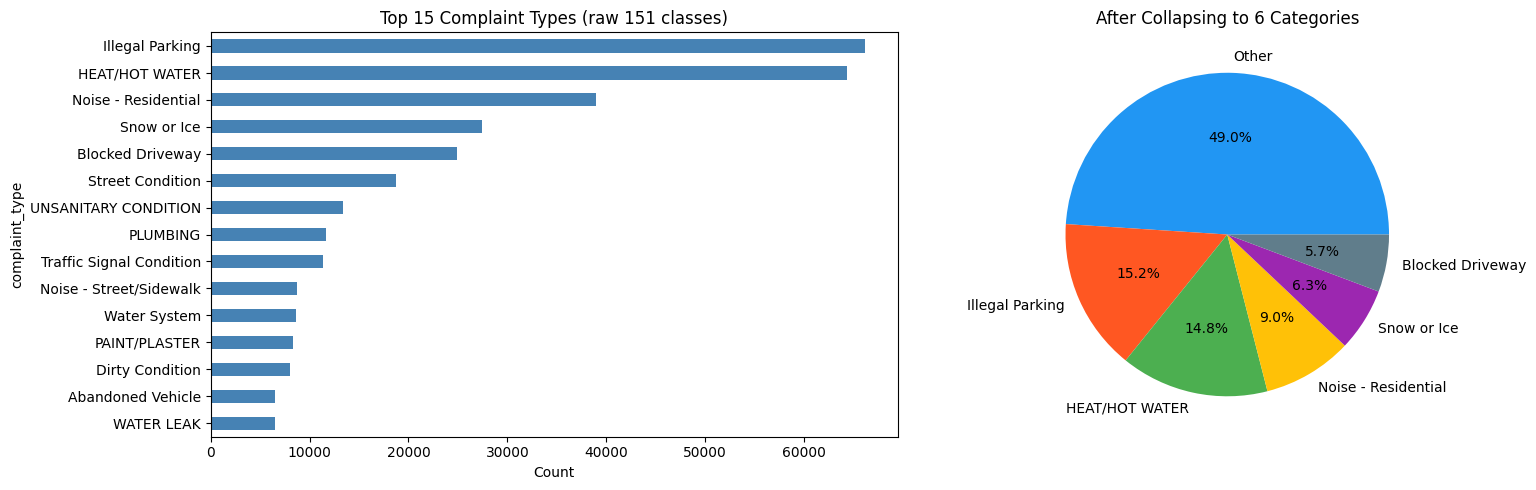


Top 5 categories as % of total:
complaint_type
Other                  49.0
Illegal Parking        15.2
HEAT/HOT WATER         14.8
Noise - Residential     9.0
Snow or Ice             6.3
Blocked Driveway        5.7


In [8]:
# 2. Target Variable — Class Distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Top 15 raw complaint types
df['complaint_type'].value_counts().head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Complaint Types (raw 151 classes)')
axes[0].set_xlabel('Count')
axes[0].invert_yaxis()

# After collapsing to 6 categories
cat_counts = df['complaint_type'].apply(
    lambda x: x if x in ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
                          'Snow or Ice','Blocked Driveway'] else 'Other'
)
cat_counts.value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1],
    colors=['#2196F3','#FF5722','#4CAF50','#FFC107','#9C27B0','#607D8B'])
axes[1].set_title('After Collapsing to 6 Categories')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

print('\nTop 5 categories as % of total:')
print(cat_counts.value_counts(normalize=True).mul(100).round(1).to_string())


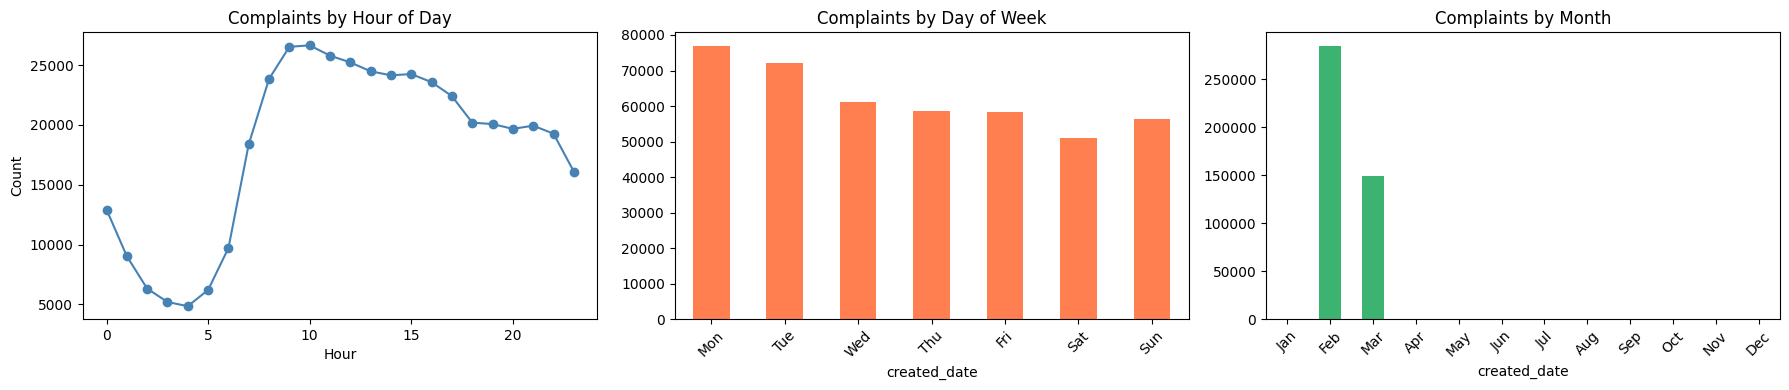

In [9]:
# 3. Temporal Patterns
df['created_date'] = pd.to_datetime(df['created_date'])

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# By hour of day
df['created_date'].dt.hour.value_counts().sort_index().plot(
    ax=axes[0], color='steelblue', marker='o')
axes[0].set_title('Complaints by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Count')

# By day of week — map numbers to names instead of replacing index
day_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
day_counts = (df['created_date'].dt.dayofweek
              .map(day_map)
              .value_counts()
              .reindex(['Mon','Tue','Wed','Thu','Fri','Sat','Sun']))
day_counts.plot(ax=axes[1], kind='bar', color='coral')
axes[1].set_title('Complaints by Day of Week')
axes[1].tick_params(axis='x', rotation=45)

# By month — map numbers to names instead of replacing index
month_map = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
             7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}
month_counts = (df['created_date'].dt.month
                .map(month_map)
                .value_counts()
                .reindex(['Jan','Feb','Mar','Apr','May','Jun',
                          'Jul','Aug','Sep','Oct','Nov','Dec']))
month_counts.plot(ax=axes[2], kind='bar', color='mediumseagreen')
axes[2].set_title('Complaints by Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


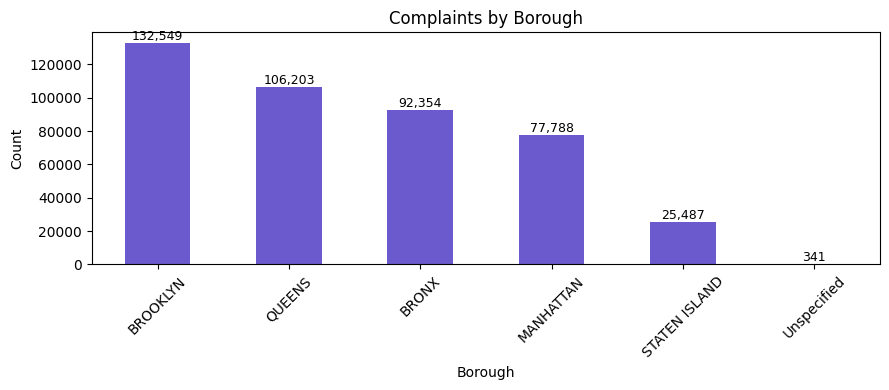

In [10]:
# 4. Geographic Distribution — Borough
fig, ax = plt.subplots(figsize=(9, 4))
df['borough'].value_counts().plot(kind='bar', ax=ax, color='slateblue')
ax.set_title('Complaints by Borough')
ax.set_xlabel('Borough')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


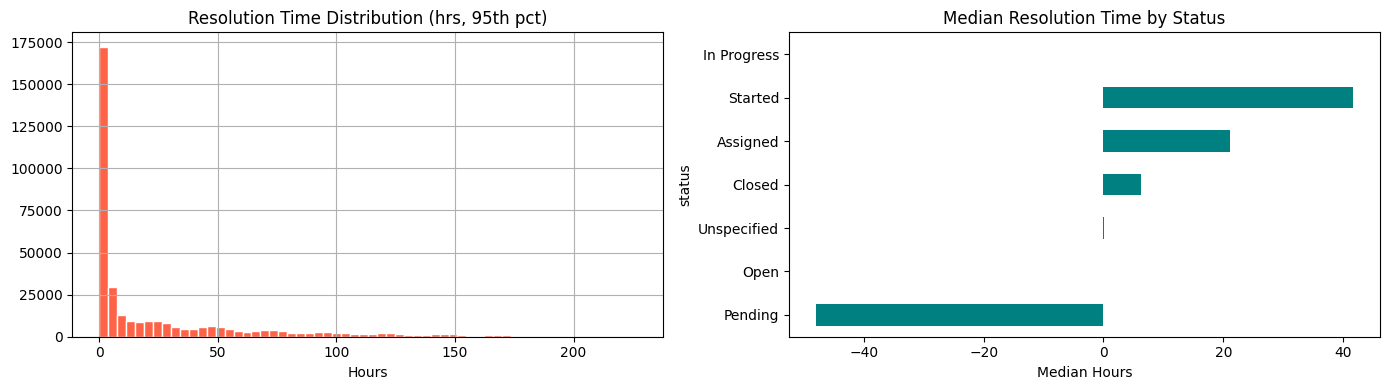

Resolution time stats (hours):
count    384642.0
mean         48.6
std         106.0
min        -240.0
25%           1.0
50%           5.9
75%          49.6
max        7274.1
Name: resolution_hours, dtype: float64


In [11]:
# 5. Resolution Time Distribution
df['closed_date'] = pd.to_datetime(df['closed_date'])
df['resolution_hours'] = (
    df['closed_date'] - df['created_date']
).dt.total_seconds() / 3600

rt = df['resolution_hours'].dropna()
rt = rt[(rt >= 0) & (rt <= rt.quantile(0.95))]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
rt.hist(bins=60, ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Resolution Time Distribution (hrs, 95th pct)')
axes[0].set_xlabel('Hours')

df.groupby('status')['resolution_hours'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='teal')
axes[1].set_title('Median Resolution Time by Status')
axes[1].set_xlabel('Median Hours')
plt.tight_layout()
plt.show()

print('Resolution time stats (hours):')
print(df['resolution_hours'].describe().round(1))


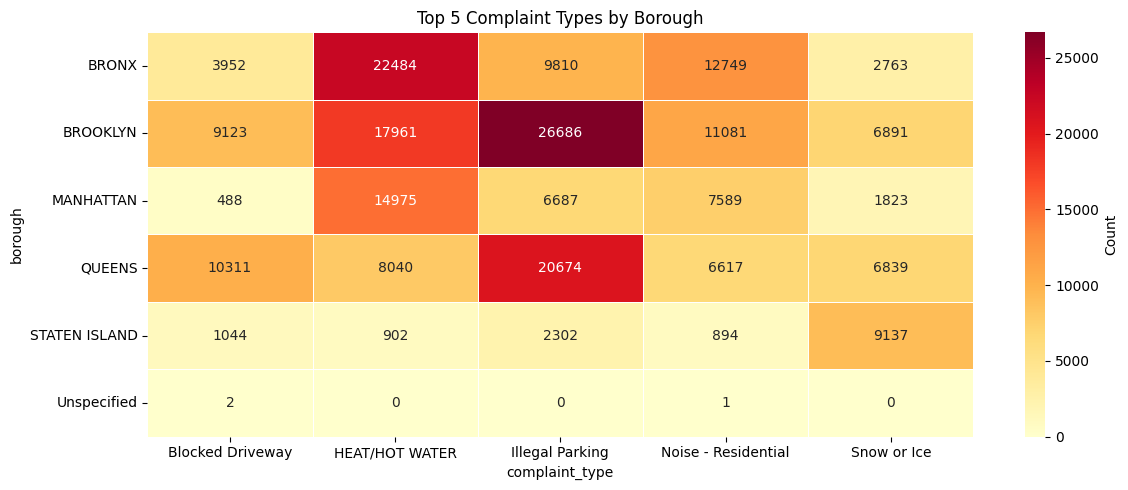

In [12]:
# 6. Complaint Type vs Borough Heatmap
top_5 = ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
         'Snow or Ice','Blocked Driveway']
heat_df = df[df['complaint_type'].isin(top_5)].copy()
pivot = heat_df.groupby(['borough','complaint_type']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Count'})
plt.title('Top 5 Complaint Types by Borough')
plt.tight_layout()
plt.show()


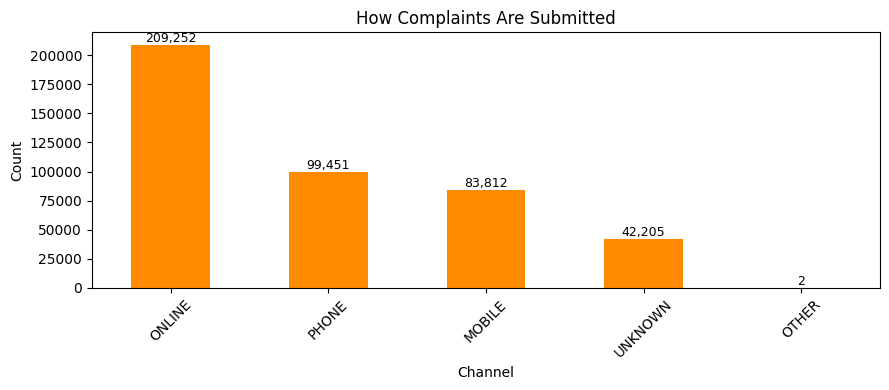

In [13]:
# 7. Submission Channel
fig, ax = plt.subplots(figsize=(9, 4))
df['open_data_channel_type'].value_counts().plot(
    kind='bar', ax=ax, color='darkorange')
ax.set_title('How Complaints Are Submitted')
ax.set_xlabel('Channel')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{p.get_height():,.0f}', (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()


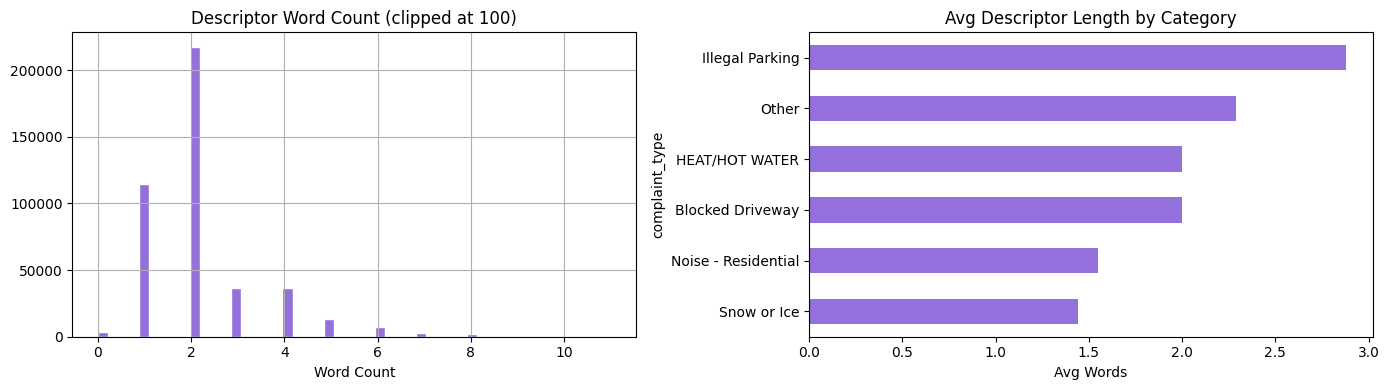

Descriptor word count stats:
count    434722.0
mean          2.2
std           1.3
min           0.0
25%           1.0
50%           2.0
75%           2.0
max          11.0
Name: text_length, dtype: float64


In [14]:
# 8. Descriptor Text Length Analysis
df['text_length'] = df['descriptor'].fillna('').apply(lambda x: len(x.split()))

top_5 = ['Illegal Parking','HEAT/HOT WATER','Noise - Residential',
         'Snow or Ice','Blocked Driveway']
cat_label = df['complaint_type'].apply(lambda x: x if x in top_5 else 'Other')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['text_length'].clip(upper=100).hist(bins=50, ax=axes[0], color='mediumpurple',
                                        edgecolor='white')
axes[0].set_title('Descriptor Word Count (clipped at 100)')
axes[0].set_xlabel('Word Count')

df.groupby(cat_label)['text_length'].mean().sort_values().plot(
    kind='barh', ax=axes[1], color='mediumpurple')
axes[1].set_title('Avg Descriptor Length by Category')
axes[1].set_xlabel('Avg Words')

plt.tight_layout()
plt.show()

print('Descriptor word count stats:')
print(df['text_length'].describe().round(1))


---

## Part 2: Data Preparation & Train-Test Split

**The Problem:** Before training any models, we need to:
1. Handle missing values
2. Encode categorical variables
3. Scale numeric features (important for Logistic Regression)
4. Split our data into training and test sets

**Note:** You can reference your Unit 2 capstone code for handling missing values, encoding, and scaling - the techniques are the same!

### Task 2a: Prepare Features

Create a function that:
 Steps:
    1. Drop non-predictive columns (unique_key, resolution_description, agency_name, descriptor)

    2. Engineer time-based features from created_date and closed_date

    3. Fill missing values

    4. Encode status ordinally

    5. One-hot encode borough, open_data_channel_type, and agency
    
    6. Scale numeric features using StandardScaler

In [15]:
def prepare_features(df):
    """
    Prepare features for machine learning on the urbanpulse 311 complaints dataset.
    
    Steps:
    1. Drop non-predictive columns (unique_key, resolution_description, agency_name)
    2. Engineer time-based features from created_date and closed_date
    3. Fill missing values
    4. Encode status ordinally
    5. One-hot encode borough, open_data_channel_type, and agency
    6. Scale numeric features using StandardScaler
    
    Args:
        df (pd.DataFrame): The raw DataFrame
        
    Returns:
        pd.DataFrame: The prepared DataFrame with all numeric columns (scaled)
    """
    from sklearn.preprocessing import StandardScaler

    df_prep = df.copy()

    # Step 1: Drop non-predictive / high-cardinality columns
    df_prep = df_prep.drop(
        columns=['unique_key', 'resolution_description', 'agency_name'],
        errors='ignore'
    )

    # Step 2: Engineer time-based features from dates
    df_prep['created_date'] = pd.to_datetime(df_prep['created_date'])
    df_prep['closed_date']  = pd.to_datetime(df_prep['closed_date'])

    df_prep['created_hour']      = df_prep['created_date'].dt.hour
    df_prep['created_dayofweek'] = df_prep['created_date'].dt.dayofweek
    df_prep['created_month']     = df_prep['created_date'].dt.month
    df_prep['resolution_hours']  = (
        df_prep['closed_date'] - df_prep['created_date']
    ).dt.total_seconds() / 3600

    df_prep = df_prep.drop(columns=['created_date', 'closed_date'])

    # Step 3: Fill missing values with median
    df_prep['resolution_hours'] = df_prep['resolution_hours'].fillna(
        df_prep['resolution_hours'].median()
    )

    # Step 4: Encode status ordinally
    status_mapping = {
        'Open': 0, 'Assigned': 1, 'Started': 2,
        'In Progress': 3, 'Pending': 4, 'Closed': 5, 'Unspecified': 0
    }
    df_prep['status'] = df_prep['status'].map(status_mapping).fillna(0).astype(int)

    # Step 5: One-hot encode categorical columns
    df_prep = pd.get_dummies(
        df_prep, columns=['borough', 'open_data_channel_type', 'agency'], dtype=int
    )

    # Step 6: Scale numeric features
    scaler = StandardScaler()
    exclude_cols = {'status', 'complaint_type', 'descriptor'}
    onehot_prefixes = ('borough_', 'open_data_channel_type_', 'agency_')
    numeric_cols = [
        col for col in df_prep.select_dtypes(include=['int64', 'float64']).columns
        if col not in exclude_cols and not col.startswith(onehot_prefixes)
    ]
    df_prep[numeric_cols] = scaler.fit_transform(df_prep[numeric_cols])

    df_prep = df_prep.fillna(0)

    return df_prep


### Verification: `prepare_features()` for 311 Dataset

| Check | What it verifies |
|-------|------------------|
| **Dropped columns** | `unique_key`, `resolution_description`, `agency_name`, `created_date`, `closed_date` are removed |
| **No missing values** | All nulls filled (e.g., `resolution_hours` median-filled) |
| **Status encoding** | Ordinal encoded 0–5 (Open → Closed) |
| **One-hot encoding** | `borough` (6 cols), `open_data_channel_type` (5 cols), `agency` (14 cols) — originals removed |
| **Engineered features** | `created_hour`, `created_dayofweek`, `created_month`, `resolution_hours` exist |
| **Summary print** | Shape, missing value count, and column list |

In [16]:
# ============================================================
# ⚠️  DO NOT MODIFY THIS CELL - VERIFICATION TESTS ONLY  ⚠️
# ============================================================

df_prepared = prepare_features(df)

# Basic Verification
assert df_prepared is not None, "Function returned None"
assert 'unique_key' not in df_prepared.columns, "unique_key should be dropped"
assert 'resolution_description' not in df_prepared.columns, "resolution_description should be dropped"
assert 'agency_name' not in df_prepared.columns, "agency_name should be dropped"
assert 'created_date' not in df_prepared.columns, "created_date should be dropped"
assert 'closed_date' not in df_prepared.columns, "closed_date should be dropped"
assert df_prepared.isnull().sum().sum() == 0, f"Still have {df_prepared.isnull().sum().sum()} missing values!"
assert df_prepared['status'].dtype in ['int64', 'int32', 'float64'], "status should be numeric"
assert 'complaint_type' in df_prepared.columns, "Missing target column complaint_type"
assert 'created_hour' in df_prepared.columns, "Missing feature created_hour"
assert 'created_dayofweek' in df_prepared.columns, "Missing feature created_dayofweek"
assert 'created_month' in df_prepared.columns, "Missing feature created_month"
assert 'resolution_hours' in df_prepared.columns, "Missing feature resolution_hours"
borough_cols = [col for col in df_prepared.columns if col.startswith('borough_')]
assert len(borough_cols) > 0, "borough should be one-hot encoded"
channel_cols = [col for col in df_prepared.columns if col.startswith('open_data_channel_type_')]
assert len(channel_cols) > 0, "open_data_channel_type should be one-hot encoded"
agency_cols = [col for col in df_prepared.columns if col.startswith('agency_')]
assert len(agency_cols) > 0, "agency should be one-hot encoded"
print("[PASS] Part 2a Preparation Tests Passed!")
print(f"\nPrepared DataFrame: {df_prepared.shape[0]} rows, {df_prepared.shape[1]} columns")
print(f"Missing values: {df_prepared.isnull().sum().sum()}")
print(f"Columns: {list(df_prepared.columns)}")


[PASS] Part 2a Preparation Tests Passed!

Prepared DataFrame: 434722 rows, 33 columns
Missing values: 0
Columns: ['complaint_type', 'descriptor', 'status', 'resolution_hours', 'text_length', 'created_hour', 'created_dayofweek', 'created_month', 'borough_BRONX', 'borough_BROOKLYN', 'borough_MANHATTAN', 'borough_QUEENS', 'borough_STATEN ISLAND', 'borough_Unspecified', 'open_data_channel_type_MOBILE', 'open_data_channel_type_ONLINE', 'open_data_channel_type_OTHER', 'open_data_channel_type_PHONE', 'open_data_channel_type_UNKNOWN', 'agency_DCWP', 'agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD', 'agency_OOS', 'agency_OTI', 'agency_TLC']


In [17]:
df_prepared.head(10)

,complaint_type,descriptor,status,resolution_hours,text_length,created_hour,created_dayofweek,created_month,borough_BRONX,borough_BROOKLYN,borough_MANHATTAN,borough_QUEENS,borough_STATEN ISLAND,borough_Unspecified,open_data_channel_type_MOBILE,open_data_channel_type_ONLINE,open_data_channel_type_OTHER,open_data_channel_type_PHONE,open_data_channel_type_UNKNOWN,agency_DCWP,agency_DEP,agency_DHS,agency_DOB,agency_DOE,agency_DOHMH,agency_DOT,agency_DPR,agency_DSNY,agency_HPD,agency_NYPD,agency_OOS,agency_OTI,agency_TLC
0,HEAT/HOT WATER,ENTIRE BUILDING,5,-0.131197,-0.157592,14,4,2,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
1,PLUMBING,WATER SUPPLY,5,0.096927,-0.157592,10,2,3,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,Illegal Parking,Posted Parking Sign Violation,5,-0.422461,1.425179,11,3,3,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
3,HEAT/HOT WATER,ENTIRE BUILDING,5,0.167177,-0.157592,23,4,2,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,Illegal Parking,Blocked Crosswalk,5,-0.424837,-0.157592,10,1,2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
5,Illegal Parking,Posted Parking Sign Violation,5,-0.430019,1.425179,13,6,3,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
6,Noise - Street/Sidewalk,Loud Music/Party,5,-0.404535,-0.157592,4,5,2,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0
7,HEAT/HOT WATER,APARTMENT ONLY,5,0.125192,-0.157592,13,4,2,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8,HEAT/HOT WATER,ENTIRE BUILDING,5,-0.133769,-0.157592,8,1,3,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
9,Non-Residential Heat,Inadequate or No Heat,3,-0.375002,1.425179,11,0,2,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0


---

## Part 2b: Complaint Category Mapping

**Your Task:** Map the 151 complaint types down to the top 5 + an `"Other"` bucket (6 classes total). This makes classification practical for city operations teams.

In [18]:
def create_complaint_categories(df: pd.DataFrame) -> pd.DataFrame:
    """
    Map complaint types to the top 5 categories + "Other" (6 classes total).

    The top 5 categories are:
    - Illegal Parking
    - HEAT/HOT WATER
    - Noise - Residential
    - Snow or Ice
    - Blocked Driveway

    Everything else maps to "Other". This gives you 6 classes total —
    a much more manageable classification problem than 186 categories.
    """
    top_5 = {
        "Illegal Parking",
        "HEAT/HOT WATER",
        "Noise - Residential",
        "Snow or Ice",
        "Blocked Driveway",
    }
    
    df = df.copy()
    df["complaint_type"] = df["complaint_type"].where(
        df["complaint_type"].isin(top_5), other="Other"
    )
    return df


In [19]:
df_categorized = create_complaint_categories(df_prepared)

# Basic Verification
assert df_categorized is not None, "Function returned None"
assert 'complaint_type' in df_categorized.columns, "Missing complaint_type column"
assert df_categorized['complaint_type'].nunique() == 6, \
    f"Expected 6 categories, got {df_categorized['complaint_type'].nunique()}"
assert 'descriptor' in df_categorized.columns, \
    "Missing descriptor column — check prepare_features drops only unique_key, resolution_description, agency_name"

print("[PASS] Part 2b Categorization Tests Passed!")
print(f"  Shape         : {df_categorized.shape}")
print(f"  Has descriptor: {'descriptor' in df_categorized.columns}")
print(f"\nComplaint type distribution:")
print(df_categorized['complaint_type'].value_counts(normalize=True).mul(100).round(1).to_string())


[PASS] Part 2b Categorization Tests Passed!
  Shape         : (434722, 33)
  Has descriptor: True

Complaint type distribution:
complaint_type
Other                  49.0
Illegal Parking        15.2
HEAT/HOT WATER         14.8
Noise - Residential     9.0
Snow or Ice             6.3
Blocked Driveway        5.7


---

## Part 2c: Text Preprocessing

**Your Task:** Clean the `descriptor` column so it can be used as a text feature. Real citizen-submitted text is messy — normalize it into clean, lowercase tokens.

In [20]:
import re

def preprocess_311_text(text: str) -> str:
    """
    Clean and normalize 311 complaint text for classification.
    """
    if not isinstance(text, str) or not text.strip():
        return ""

    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs and emails BEFORE punctuation stripping
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Remove ordinal numbers whole (5th, 42nd, 1st, 3rd, etc.)
    text = re.sub(r'\b\d+(?:st|nd|rd|th)\b', '', text)

    # 4. Strip non-ASCII characters (handles Chinese, Spanish, etc.)
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # 5. Remove all punctuation except apostrophes
    text = re.sub(r"[^\w\s']", ' ', text)

    # 6. Remove remaining digit sequences
    text = re.sub(r'\d+', '', text)

    # 7. Collapse repeated characters ("sooooo" -> "soo")
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # 8. Normalize whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 9. Truncate to 100 words (well under the 5000-char limit)
    words = text.split()
    if len(words) > 100:
        text = ' '.join(words[:100])

    return text


In [21]:
# Test the function
test_cases = [
    "This is a test! Visit http://example.com for more info. Contact me at user@example.com.",
    "Pothole on 5th Ave near 42nd St. Please fix!",
    "So many cars parked illegally on my street. It's a nightmare! Sooooo annoying!!!",
    "噪音投诉！晚上音乐太吵了！",
    "Heat not working since 12/01/2023. Please send someone! My address is 123 Main St, zip 90210."
]
for i, text in enumerate(test_cases):
    processed = preprocess_311_text(text)
    print(f"Test Case {i+1}:\nOriginal:  {text}\nProcessed: {processed}\n{'-'*50}")

# Apply to descriptor column
df_categorized['descriptor'] = df_categorized['descriptor'].fillna('').apply(preprocess_311_text)

# Basic Verification
assert 'descriptor' in df_categorized.columns, "Missing descriptor column"
assert df_categorized['descriptor'].isnull().sum() == 0, "There are still missing values in the descriptor column"
print("[PASS] Part 2c Text Preprocessing Tests Passed!")
print(f"\nSample processed descriptors:\n{df_categorized['descriptor'].head(10)}")


Test Case 1:
Original:  This is a test! Visit http://example.com for more info. Contact me at user@example.com.
Processed: this is a test visit for more info contact me at
--------------------------------------------------
Test Case 2:
Original:  Pothole on 5th Ave near 42nd St. Please fix!
Processed: pothole on ave near st please fix
--------------------------------------------------
Test Case 3:
Original:  So many cars parked illegally on my street. It's a nightmare! Sooooo annoying!!!
Processed: so many cars parked illegally on my street it's a nightmare soo annoying
--------------------------------------------------
Test Case 4:
Original:  噪音投诉！晚上音乐太吵了！
Processed: 
--------------------------------------------------
Test Case 5:
Original:  Heat not working since 12/01/2023. Please send someone! My address is 123 Main St, zip 90210.
Processed: heat not working since please send someone my address is main st zip
--------------------------------------------------
[PASS] Part 2c Text Pr